In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Type of polarizations:

$i)$ $\gamma=0$, $\alpha=0$ if the polarization is linear, 

$ii)$ $\gamma=0$, $\alpha=1$ if the polarization is circular, and 

$iii)$ $\gamma=1$, $\alpha=0$ if the polarization is radial.


### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [5]:
s0val = [1, 10, 80]

Finding a profile with nodes: [1 0 0]
Final precision: U0 = [1.209959 0.       0.      ] radius 30.54758123082615


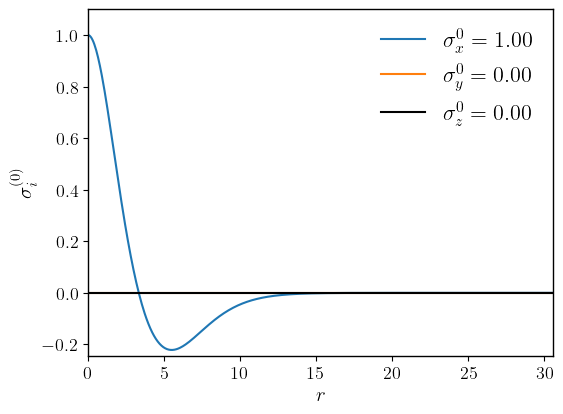

Finding a profile with nodes: [1 0 0]
Final precision: U0 = [12.09959002  0.          0.        ] radius 10.084148522410214


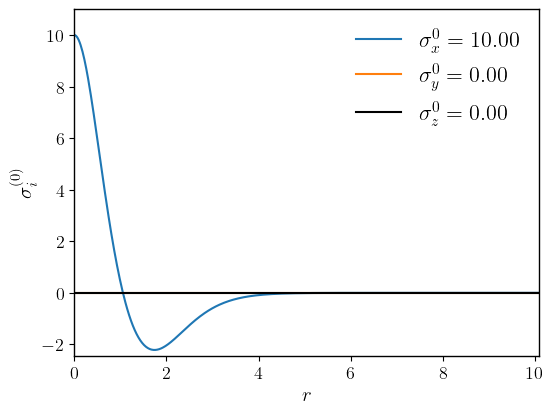

Finding a profile with nodes: [1 0 0]
Final precision: U0 = [96.79672016  0.          0.        ] radius 3.611114944472733


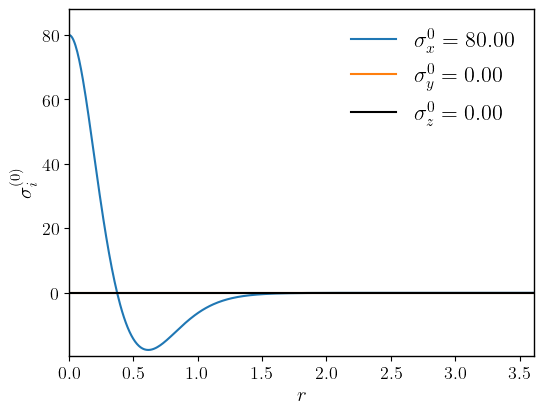

In [6]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx, ny, nz = 1, 0, 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx, ny, nz]  # list of node info

p1x = 0  # the first derivative value (p1x), the latter is zero
p0y, p1y = 0, 0  # The same in y-axes
p0z, p1z = 0, 0  # The same in z-axes
u1x, u1y, u1z = 0, 0, 0  # The first derivatives of the x, y, and z effective potential components are all zero.

rmax = 1000  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 158]
Uyint = [0, 0]
Uzint = [0, 0]
Uintrs = [Uxint, Uyint, Uzint]
numFields = len(Uintrs)

met = 'DOP853'
gamma = 0 # 1 radial
Rtol = 1e-13 
Atol = 1e-15

datos = []
for p0x in s0val:  # The central amplitude of \sigma_x (p0x) and
    Ini0 = [p0x, p1x, p0y, p1y, p0z, p1z, u1x, u1y, u1z]  # boundary conditions list
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)
    
    #[U0x, U0y, U0z, rTmax, [p0x, p0y, p0z], nodos, LambT]
    datos.append([u0Val[0], u0Val[1], u0Val[2], rTmax, [p0x, p0y, p0z], nodos, LambT])

Mass values: [7.7139513271556215, 7.7139513271556215, 7.7139513271556215]
Eigenvalues of energy: [-0.9162747907073074, -2.1262337926865933, -2.1262337926865933]


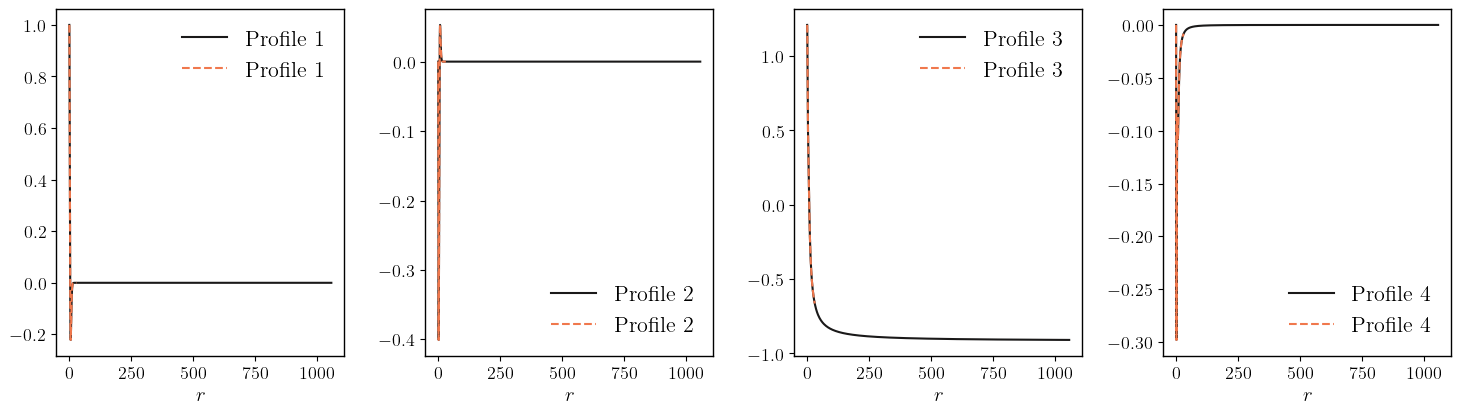

Mass values: [24.393656260160544, 24.393656260160544, 24.393656260160544]
Eigenvalues of energy: [-9.1627483359016, -21.262338355694503, -21.262338355694503]


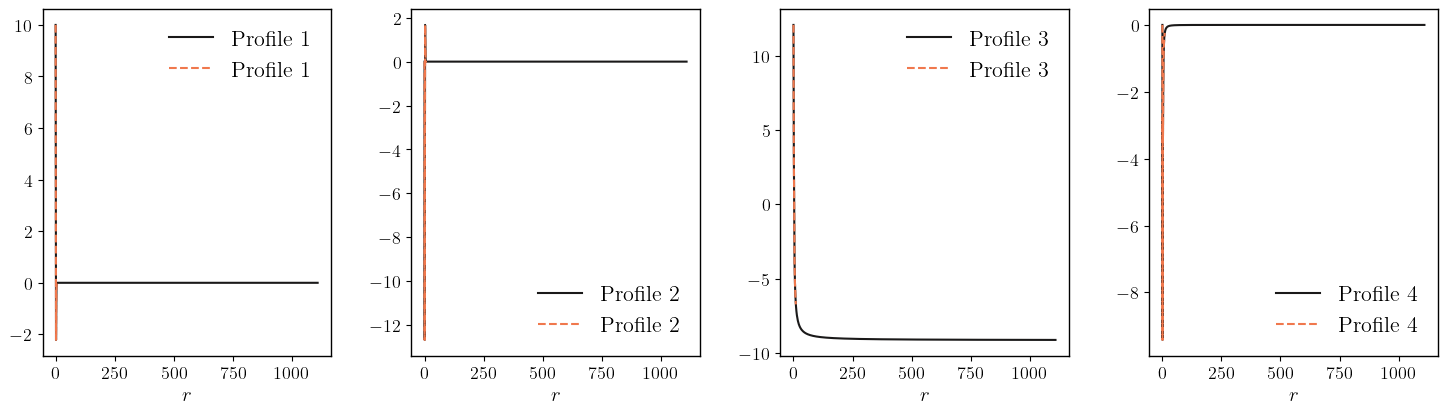

Mass values: [68.99567933905685, 68.99567933905685, 68.99567933905685]
Eigenvalues of energy: [-73.3019877978991, -170.0987079562424, -170.0987079562424]


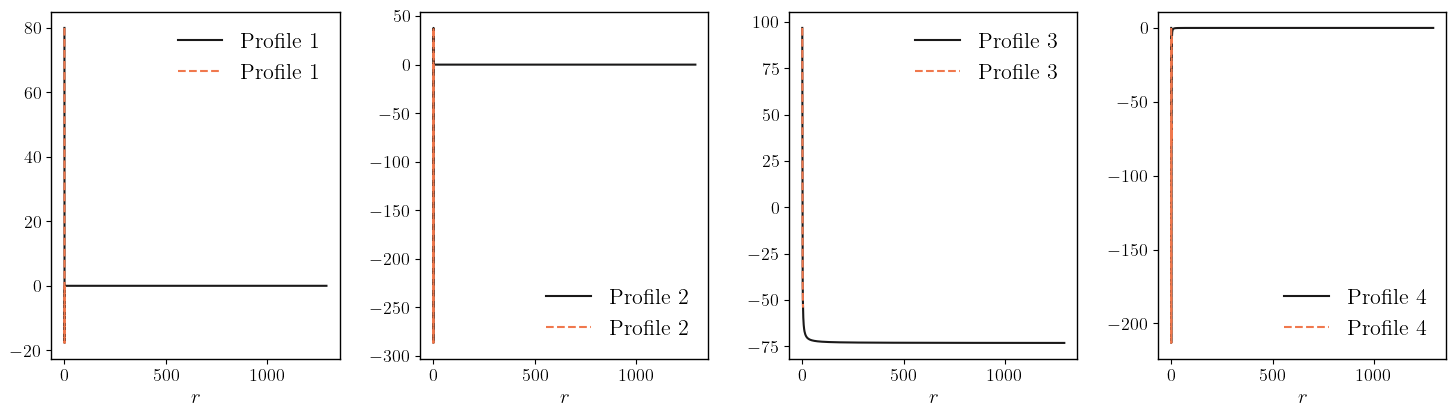

In [7]:
# Extendiendo los perfiles
Ext = 1000 #7000
Np = 1000 #int(2e06)

confidataEx = []
for confi in datos: # confidata datos
    dataEx = bg.mainExt(confi, mult=True, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])


(0.0, 35.0)

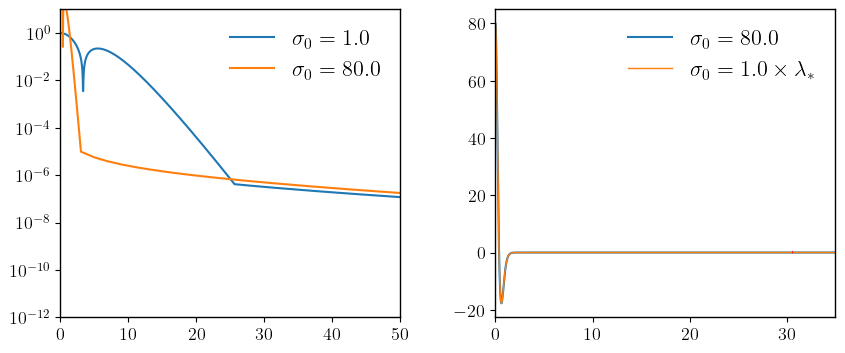

In [8]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[2]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, np.abs(sDnew), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew)[0])
ax[0].plot(rDnew1, np.abs(sDnew1), label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 50)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 10)

###########
ax[1].plot(rDnew1, sDnew1, label=r'$\sigma_0=%2.1f$'%np.abs(sDnew1)[0])

lambdaSt = sDnew1[0]
ax[1].plot(rDnew/np.sqrt(lambdaSt), sDnew*lambdaSt, lw=1, label=r'$\sigma_0=%2.1f \times \lambda_*$'%np.abs(sDnew)[0])


ax[1].vlines(x=datos[0][3], ymin=1e-9, ymax=1, color='r', lw=0.5, ls='--')
ax[1].vlines(x=datos[1][3]*np.sqrt(lambdaSt),ymin=1e-9, ymax=1, color='k', lw=0.5, ls='-')

#ax[0].set_yscale('log')
#ax[1].set_yscale('log')
#ax[1].set_ylim(-0.8, 3.01)
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 35)

In [9]:
print("lambda_* = ", lambdaSt)

lambda_* =  80.0


Testeando los autovalores

In [10]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [11]:
s0val

[1, 10, 80]

### $\sigma_0=1$

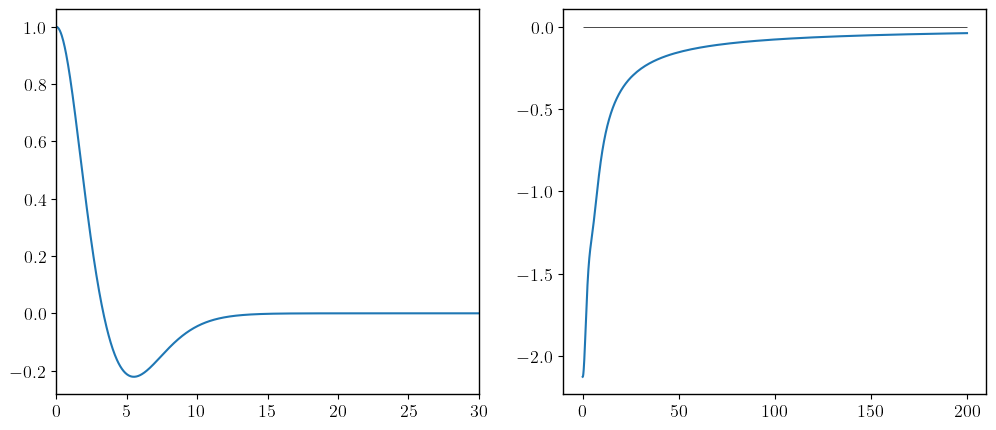

In [27]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 1
rMax = 200 # 200*(nodos+1) + 50
Nptos = 500 #int(3*rMax/4) * 2

Jval = [0, 1, 2] #, 2, 3]
lamV_list = [[0., 1.], [0., -1.], [0., 0]]   # ln, ls
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
plt.show()

lambdaVal_s1, dataExtra_s1 = [], []
for i in range(len(lamV_list)):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s1.append(lambdaVal)
    dataExtra_s1.append(dataExtra)


In [28]:
real_eigVal_s1LsP_list = []
for i in range(len(lamV_list)):
    real_eigVal_s1LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s1[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s1LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s1LsP_list.append([lamV_list[i], real_eigVal_s1LsP])


Jval = 0
[-0.00131781+1.11388109e-14j  0.00131781-9.82165868e-14j
  0.08827174-5.82906798e-01j -0.08827174-5.82906798e-01j
 -0.08827174+5.82906798e-01j  0.08827174+5.82906798e-01j]
Jval = 1
[ 0.00149275+1.40626293e-14j -0.00149275+1.80758084e-14j]
Jval = 2
[ 0.09917348+4.33064916e-15j -0.09917348+4.20898772e-15j]
##################################################
Jval = 0
[-0.00131781+1.11388109e-14j  0.00131781-9.82165868e-14j
  0.08827174-5.82906798e-01j -0.08827174-5.82906798e-01j
 -0.08827174+5.82906798e-01j  0.08827174+5.82906798e-01j]
Jval = 1
[ 0.00149275+1.40626293e-14j -0.00149275+1.80758084e-14j]
Jval = 2
[ 0.09917348+4.33064916e-15j -0.09917348+4.20898772e-15j]
##################################################
Jval = 0
[-0.00131781+1.11388109e-14j  0.00131781-9.82165868e-14j
  0.08827174-5.82906798e-01j -0.08827174-5.82906798e-01j
 -0.08827174+5.82906798e-01j  0.08827174+5.82906798e-01j]
Jval = 1
[ 0.00149275+1.40626293e-14j -0.00149275+1.80758084e-14j]
Jval = 2
[ 0.0991734

Text(0.5, 1.0, '$\\lambda=[0, -1]$')

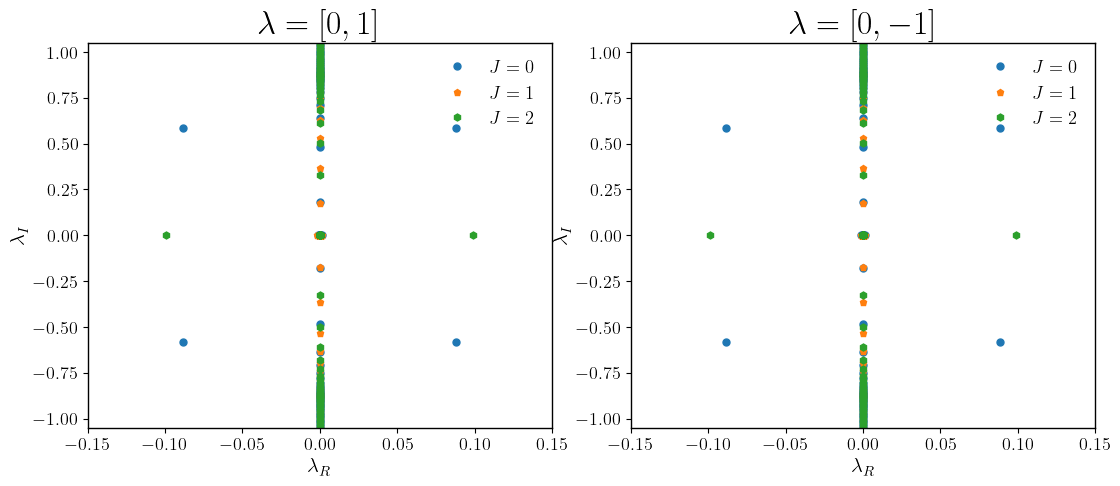

In [29]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra_s1[0]):
    _, eingVal, _ = data
    ax[0].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)


for ind, [Jval, data] in enumerate(dataExtra_s1[1]):
    _, eingVal, _ = data
    ax[1].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
for axes in ax:
    axes.legend(frameon=False, fontsize='small')
    axes.set_xlim(-0.15, 0.15)
    axes.set_ylim(-1.05, 1.05)
    axes.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
    axes.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

ax[0].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[0],))
ax[1].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[1],))


### $\sigma_0=10$

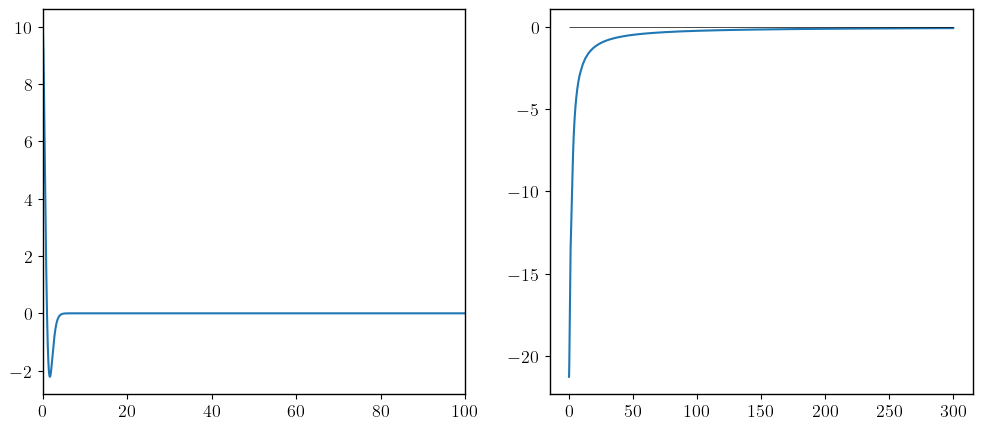

In [30]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[1]

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 1
rMax = 300 #200*(nodos+1) + 50
Nptos = 600 # int(3*rMax/4) * 2

Jval = [0, 1, 2] #, 2, 3]
lamV_list = [[0., 1.], [0., -1.], [0, 0]]   # ln, ls
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 100)
# ax[0].set_yscale('log')
plt.show()

lambdaVal_s10, dataExtra_s10 = [], []
for i in range(len(lamV_list)):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s10.append(lambdaVal)
    dataExtra_s10.append(dataExtra)

In [31]:
real_eigVal_s10LsP_list = []
for i in range(len(lamV_list)):
    real_eigVal_s10LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s10[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s10LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s10LsP_list.append([lamV_list[i], real_eigVal_s10LsP])

Jval = 0
[-0.01192301+1.43269560e-12j  0.01192301-1.77494439e-12j
 -0.88272347+5.82909749e+00j  0.88272347+5.82909749e+00j
 -0.88272347-5.82909749e+00j  0.88272347-5.82909749e+00j]
Jval = 1
[ 0.02409662+1.81370541e-13j -0.02409662+3.12006087e-14j]
Jval = 2
[ 0.99173698+8.37364888e-14j -0.99173698+9.13530438e-14j]
##################################################
Jval = 0
[-0.01192301+1.43269560e-12j  0.01192301-1.77494439e-12j
 -0.88272347+5.82909749e+00j  0.88272347+5.82909749e+00j
 -0.88272347-5.82909749e+00j  0.88272347-5.82909749e+00j]
Jval = 1
[ 0.02409662+1.81370541e-13j -0.02409662+3.12006087e-14j]
Jval = 2
[ 0.99173698+8.37364888e-14j -0.99173698+9.13530438e-14j]
##################################################
Jval = 0
[-0.01192301+1.43269560e-12j  0.01192301-1.77494439e-12j
 -0.88272347+5.82909749e+00j  0.88272347+5.82909749e+00j
 -0.88272347-5.82909749e+00j  0.88272347-5.82909749e+00j]
Jval = 1
[ 0.02409662+1.81370541e-13j -0.02409662+3.12006087e-14j]
Jval = 2
[ 0.9917369

Text(0.5, 1.0, '$\\lambda=[0, -1]$')

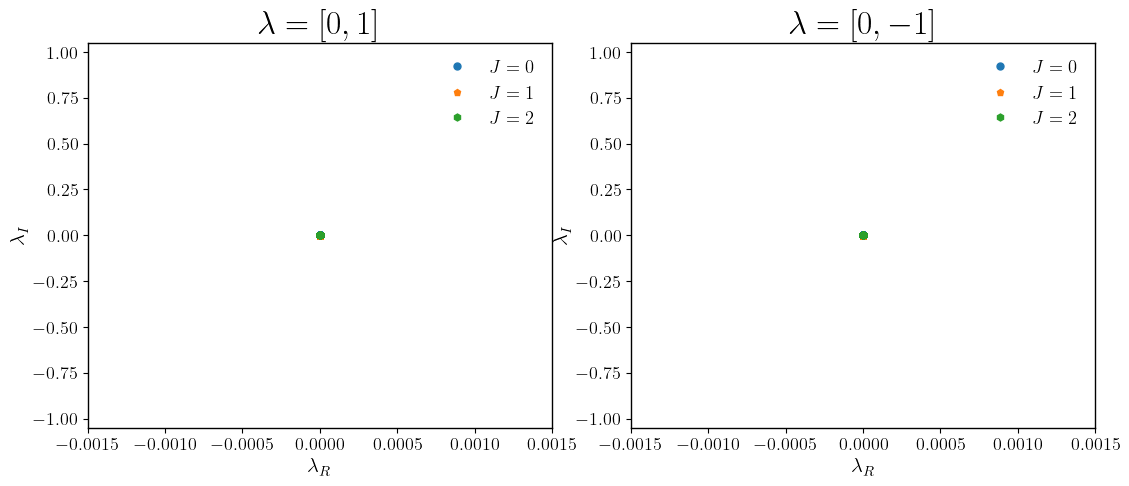

In [32]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra_s10[0]):
    _, eingVal, _ = data
    ax[0].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)


for ind, [Jval, data] in enumerate(dataExtra_s10[1]):
    _, eingVal, _ = data
    ax[1].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
for axes in ax:
    axes.legend(frameon=False, fontsize='small')
    axes.set_xlim(-0.0015, 0.0015)
    axes.set_ylim(-1.05, 1.05)
    axes.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
    axes.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

ax[0].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[0],))
ax[1].set_title(r'$\lambda=[%1d, %1d]$'%(*lamV_list[1],))

### $\sigma=80$

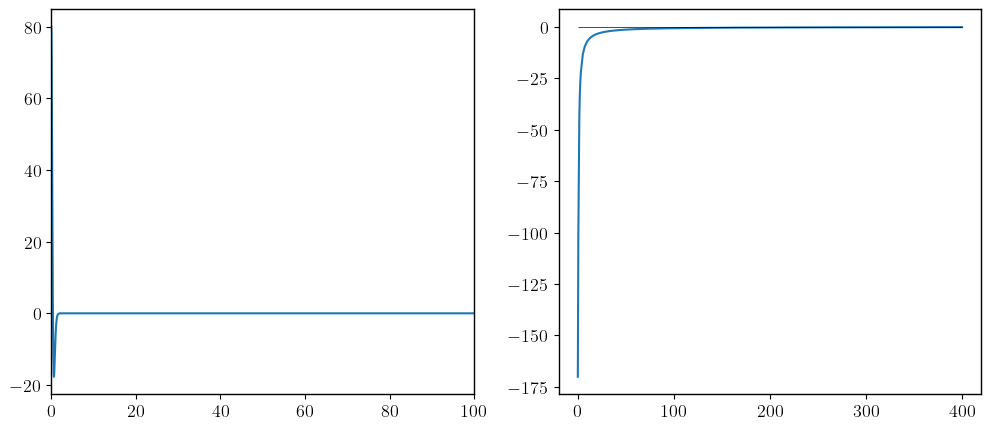

In [33]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[2]

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 1
rMax = 400 #200*(nodos+1) + 50
Nptos = 700 # int(3*rMax/4) * 2

Jval = [0, 1, 2] #, 2, 3]
lamV_list = [[0., 1.], [0., -1.], [0, 0]]   # ln, ls
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, datFunc[0][0](rad2))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 100)
# ax[0].set_yscale('log')
plt.show()

lambdaVal_s80, dataExtra_s80 = [], []
for i in range(len(lamV_list)):
    lamV = lamV_list[i]
    lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)
    lambdaVal_s80.append(lambdaVal)
    dataExtra_s80.append(dataExtra)

In [34]:
real_eigVal_s80LsP_list = []
for i in range(len(lamV_list)):
    real_eigVal_s80LsP = []
    for ind, [Jval, data] in enumerate(dataExtra_s80[i]):
        rdis, eingVal, eigVect = data
        print('Jval = %d'%Jval)
        ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
        print(eingVal[ind])
        real_eigVal_s80LsP.append([Jval, eingVal[ind]])
    print('#'*50)
    real_eigVal_s80LsP_list.append([lamV_list[i], real_eigVal_s80LsP])

Jval = 0
[ 7.06204243-46.63299795j -7.06204243-46.63299795j
 -7.06204243+46.63299795j  7.06204243+46.63299795j]
Jval = 1
[-0.18759626+9.84353080e-13j  0.18759626+2.15291084e-13j]
Jval = 2
[ 7.93390006+3.17460502e-14j -7.93390006+3.34796559e-14j]
##################################################
Jval = 0
[ 7.06204243-46.63299795j -7.06204243-46.63299795j
 -7.06204243+46.63299795j  7.06204243+46.63299795j]
Jval = 1
[-0.18759626+9.84353080e-13j  0.18759626+2.15291084e-13j]
Jval = 2
[ 7.93390006+3.17460502e-14j -7.93390006+3.34796559e-14j]
##################################################
Jval = 0
[ 7.06204243-46.63299795j -7.06204243-46.63299795j
 -7.06204243+46.63299795j  7.06204243+46.63299795j]
Jval = 1
[-0.18759626+9.84353080e-13j  0.18759626+2.15291084e-13j]
Jval = 2
[ 7.93390006+3.17460502e-14j -7.93390006+3.34796559e-14j]
##################################################


### Comparando

In [35]:
lambdaSt = s0val[1]
# ls = 1
for Jind in range(len(real_eigVal_s1LsP_list[0][1])):
    [Jval_s1, eingVal_s1] = real_eigVal_s1LsP_list[0][1][Jind]
    [Jval_s3, eingVal_s3] = real_eigVal_s10LsP_list[0][1][Jind]

    print(Jind, '==> ',  eingVal_s1 * lambdaSt, '<-->', eingVal_s3)


0 ==>  [-0.01317811+1.11388109e-13j  0.01317811-9.82165868e-13j
  0.8827174 -5.82906798e+00j -0.8827174 -5.82906798e+00j
 -0.8827174 +5.82906798e+00j  0.8827174 +5.82906798e+00j] <--> [-0.01192301+1.43269560e-12j  0.01192301-1.77494439e-12j
 -0.88272347+5.82909749e+00j  0.88272347+5.82909749e+00j
 -0.88272347-5.82909749e+00j  0.88272347-5.82909749e+00j]
1 ==>  [ 0.01492745+1.40626293e-13j -0.01492745+1.80758084e-13j] <--> [ 0.02409662+1.81370541e-13j -0.02409662+3.12006087e-14j]
2 ==>  [ 0.99173485+4.33064916e-14j -0.99173485+4.20898772e-14j] <--> [ 0.99173698+8.37364888e-14j -0.99173698+9.13530438e-14j]


In [36]:
lambdaSt = s0val[2]
# ls = 1
for Jind in range(len(real_eigVal_s1LsP_list[0][1])):
    [Jval_s1, eingVal_s1] = real_eigVal_s1LsP_list[0][1][Jind]
    [Jval_s80, eingVal_s80] = real_eigVal_s80LsP_list[0][1][Jind]

    print(Jind, '==> ',  eingVal_s1 * lambdaSt, '<-->', eingVal_s80)

0 ==>  [-0.10542487+8.91104870e-13j  0.10542487-7.85732694e-12j
  7.06173923-4.66325438e+01j -7.06173923-4.66325438e+01j
 -7.06173923+4.66325438e+01j  7.06173923+4.66325438e+01j] <--> [ 7.06204243-46.63299795j -7.06204243-46.63299795j
 -7.06204243+46.63299795j  7.06204243+46.63299795j]
1 ==>  [ 0.1194196+1.12501034e-12j -0.1194196+1.44606467e-12j] <--> [-0.18759626+9.84353080e-13j  0.18759626+2.15291084e-13j]
2 ==>  [ 7.93387878+3.46451933e-13j -7.93387878+3.36719017e-13j] <--> [ 7.93390006+3.17460502e-14j -7.93390006+3.34796559e-14j]
